Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

Load Cleaned Data

In [2]:
df = pd.read_csv("../data/processed/marketing_campaign_clean.csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


Dataset Overview

In [3]:
print("Shape:", df.shape)

df.describe().T

Shape: (2240, 27)


,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2240.0,52237.975446,25037.955891,1730.0,35538.75,51381.5,68289.75,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


Distribution of Numerical Features

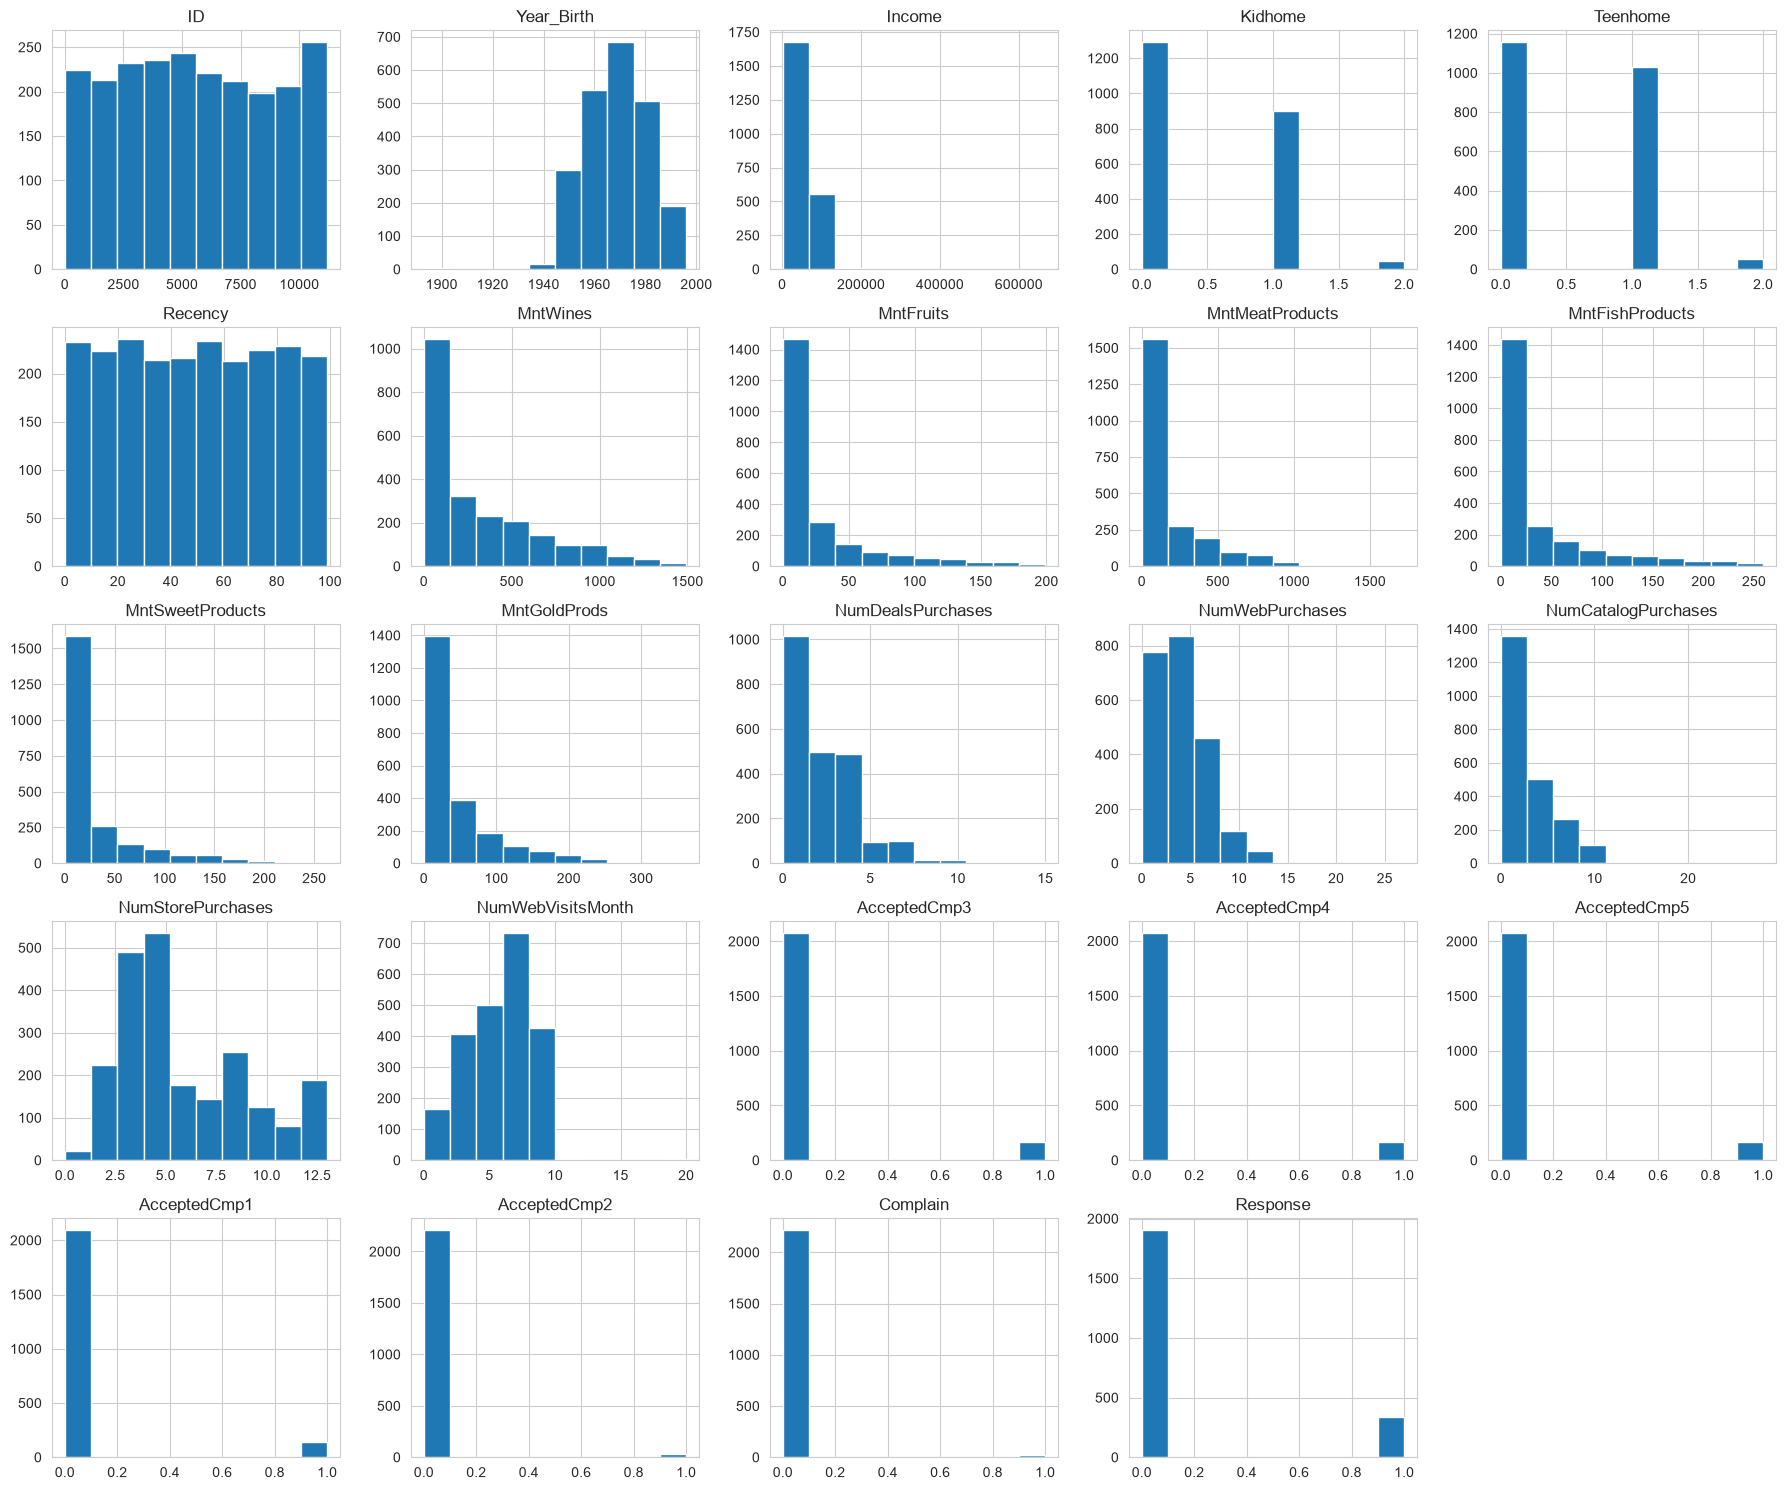

In [4]:
df.hist(figsize=(18, 15))
plt.tight_layout()
plt.show()

Correlation Heatmap

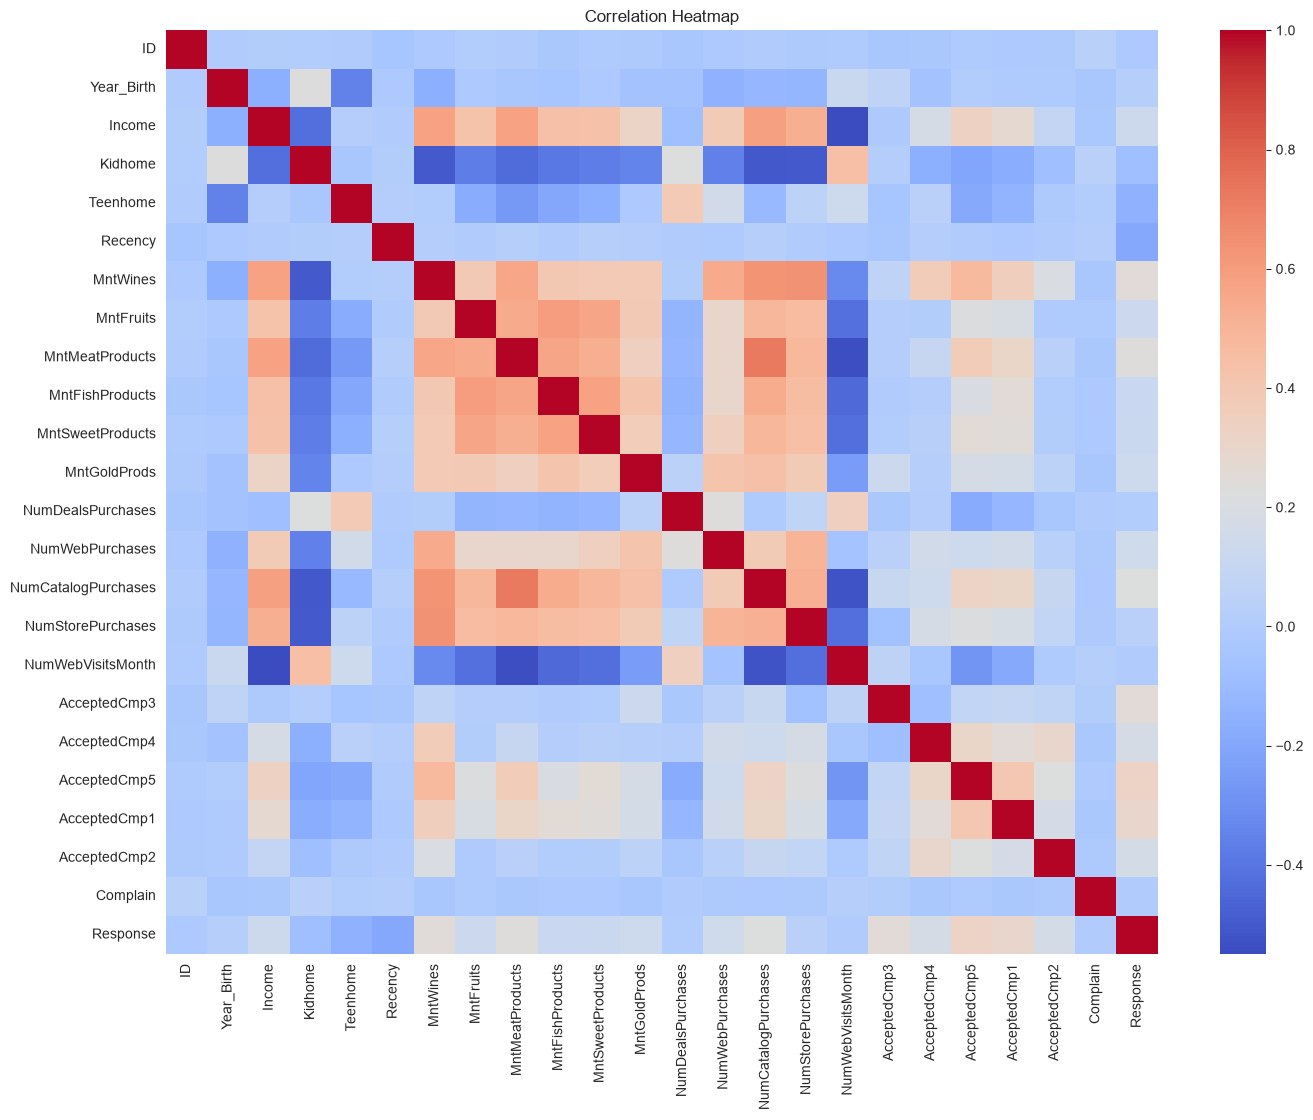

In [5]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

Income Distribution

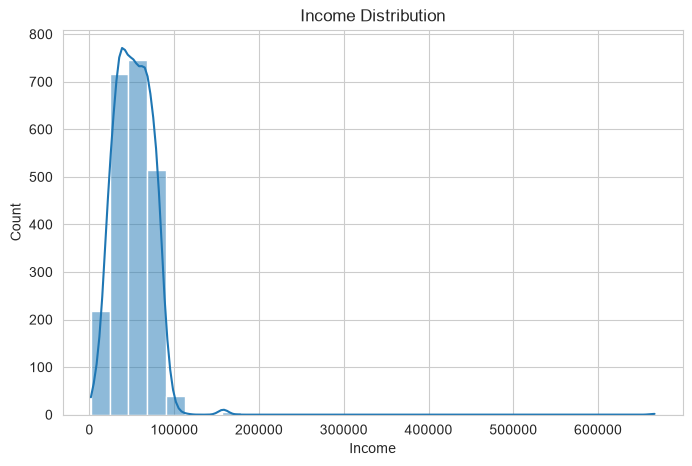

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df["Income"], bins=30, kde=True)

plt.title("Income Distribution")
plt.show()

Response Count

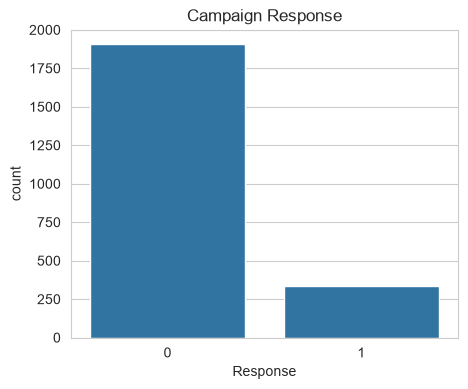

In [7]:
plt.figure(figsize=(5,4))

sns.countplot(x="Response", data=df)

plt.title("Campaign Response")
plt.show()

Education Distribution

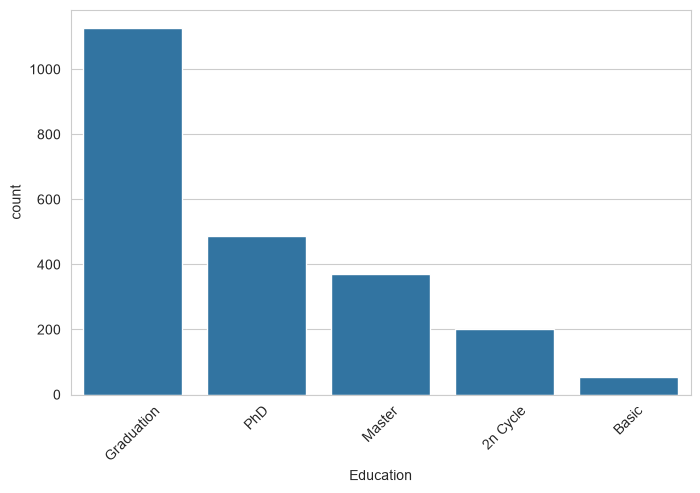

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Education",
    data=df,
    order=df["Education"].value_counts().index
)

plt.xticks(rotation=45)

plt.show()

Marital Status Distribution

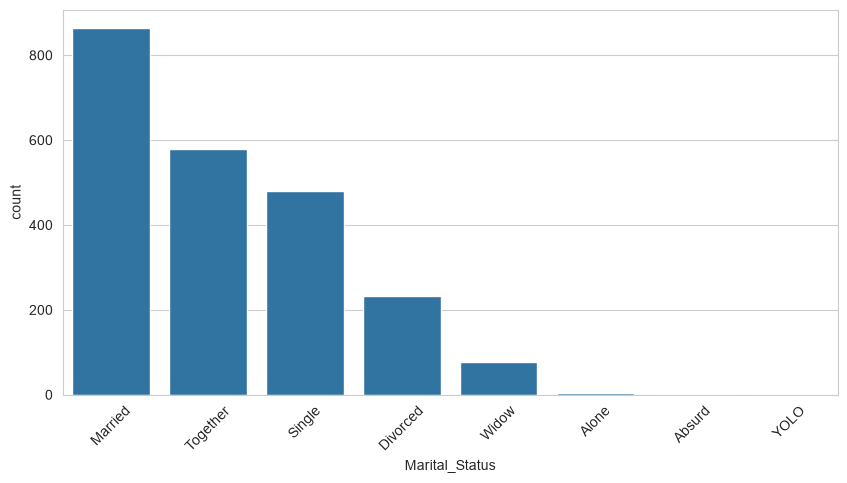

In [9]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Marital_Status",
    data=df,
    order=df["Marital_Status"].value_counts().index
)

plt.xticks(rotation=45)

plt.show()

Spending Analysis

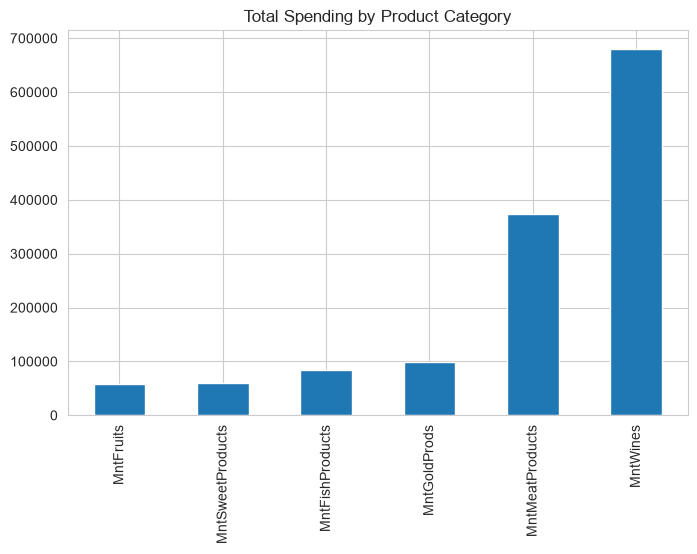

In [10]:
spending = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df[spending].sum().sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Spending by Product Category")

plt.show()

Boxplots (Outlier Detection)

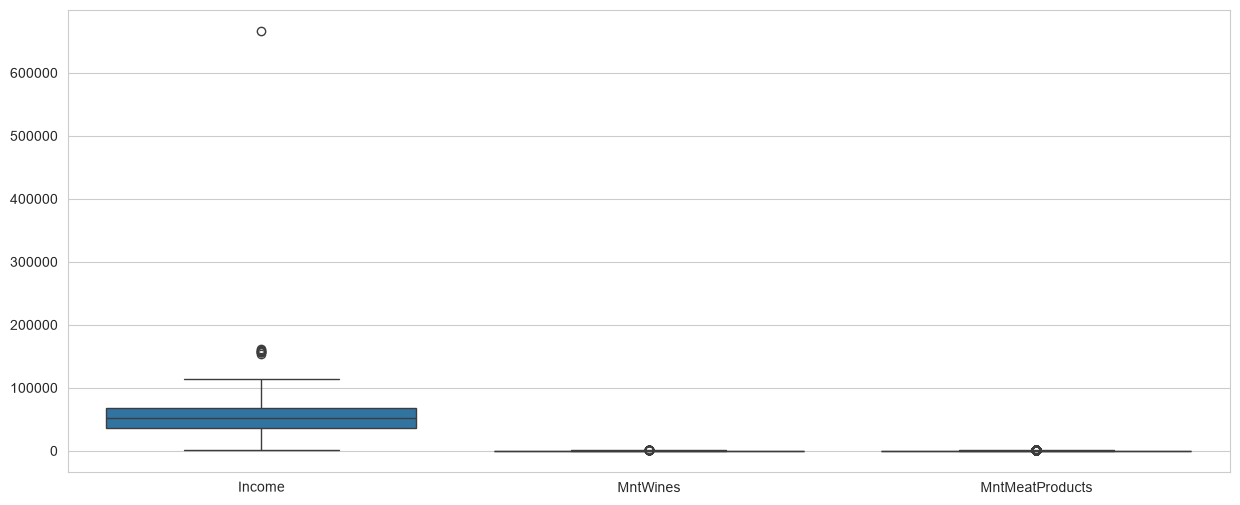

In [11]:
plt.figure(figsize=(15,6))

sns.boxplot(data=df[["Income","MntWines","MntMeatProducts"]])

plt.show()

Income vs Response

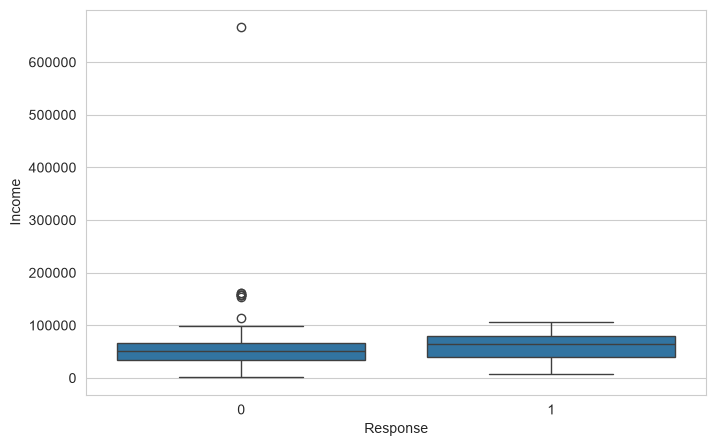

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Response", y="Income", data=df)

plt.show()

Pairplot

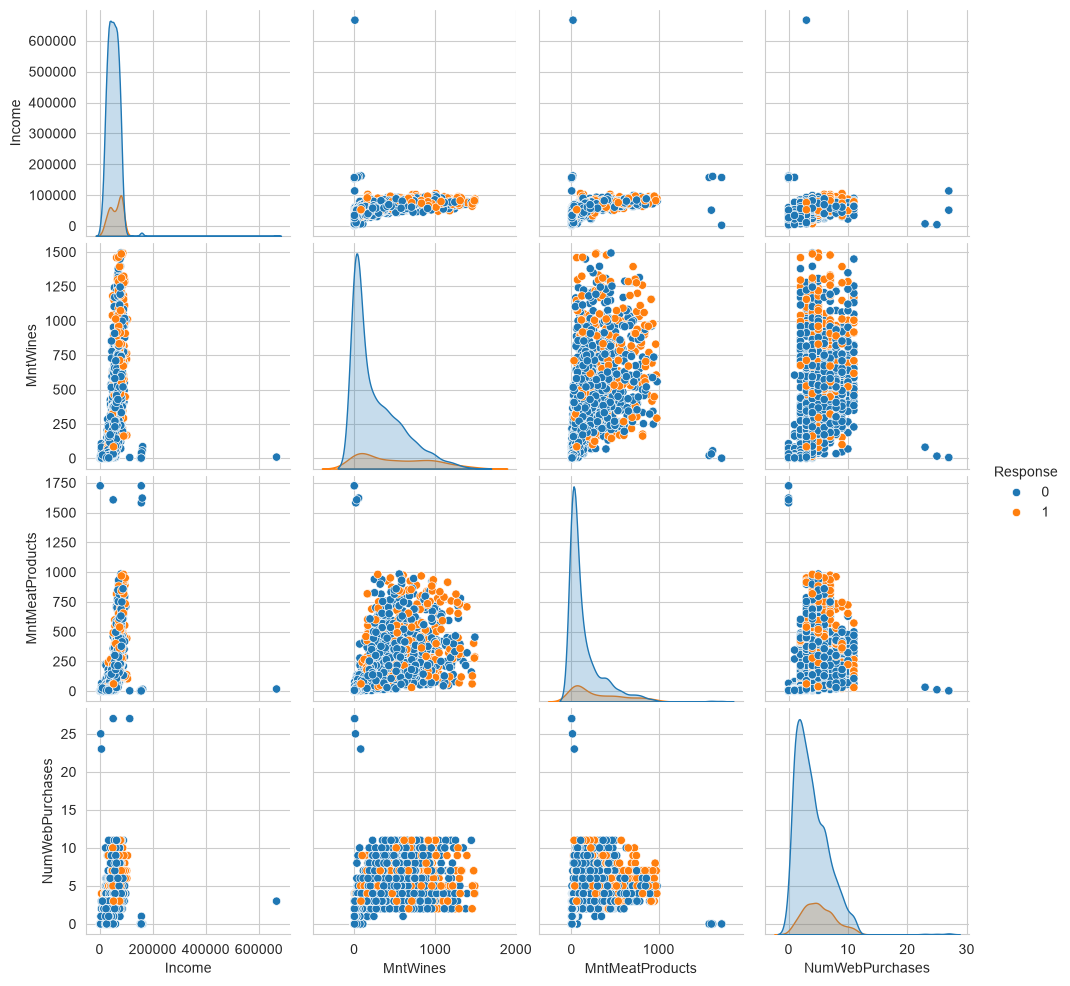

In [13]:
sns.pairplot(
    df[
        [
            "Income",
            "MntWines",
            "MntMeatProducts",
            "NumWebPurchases",
            "Response"
        ]
    ],
    hue="Response"
)

plt.show()